# Gradient Descent

This is an implementation of gradient descent using only numpy library

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load our training data set
x_train = np.array([1.0, 2.0, 3.0, 4.0, 5.0])   #features
y_train = np.array([300.0, 500.0, 700.0, 900.0, 1100.0])   #target value

# predict data set
x_test = np.array([1.0, 2.0, 3.0, 4.0, 5.0])   #features
y_test = np.array([400.0, 600.0, 800.0, 1000.0, 1200.0])   #target value

## Cost function

In order to use Linear Regression on our dataset to predict the output we need to find the values of `w` and `b`
for:

$$f_{w,b}(x) = wx + b$$

where: `w= slope` and `b= y-intercept`

### Cost Function
The way to know how wrong our model is, is by using the cost function:
$$
\begin{align}
    J_{w,b} = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2 \tag{5}\\
\end{align}
$$

The cost function is simple what it does is: it takes the predicted value 
\begin{align}
f_{w,b}(x^{(i)})
\end{align}

and from it subtracts the actual value for that given input
\begin{align}
    y^{(i)}
\end{align}


and does that for every training example.

Below we have a visualization of what the difference looks like

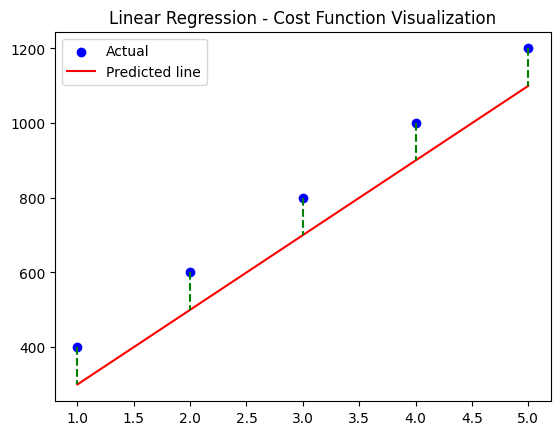

In [2]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
model = LinearRegression()
# Fit the model to the training data
model.fit(x_train.reshape(-1, 1), y_train)
# Make predictions using the trained model
y_pred = model.predict(x_test.reshape(-1, 1))


plt.scatter(x_test, y_test, color='blue', label='Actual')
plt.plot(x_test, y_pred, color='red', label='Predicted line')

# draw the error lines
for i in range(len(x_test)):
    plt.plot([x_test[i], x_test[i]], [y_test[i], y_pred[i]], color='green', linestyle='--')

plt.legend()
plt.title('Linear Regression - Cost Function Visualization')
plt.show()

## Gradient Descent

Now the role of gradient descent is it takes that cost function and uses it to find the values of w and b that give the minimum error.

$$w = w - \alpha \frac{\partial}{\partial w} J(w,b)$$

$$b = b - \alpha \frac{\partial}{\partial b} J(w,b)$$

Where the derivatives are:

$$\frac{\partial}{\partial w} J(w,b) = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) x^{(i)}$$

$$\frac{\partial}{\partial b} J(w,b) = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})$$

$a$ - alpha is the learning rate(how much of a step to take)

Beacuse in this case for w and b, the graph takes a 3d form and the gradient descent function looks like a bowl, where x and y are the paramaters and z axis is the cost function.

![gradient_descent](../images/gradient_descent_pic.png)

The formulas say: for the given cost function:  $J(w,b)$ calculate the derivative $\frac{\partial}{\partial w} J(w,b)$ to find the slope and then subtract the slope from $w$ and $b$.

What happens is a derivative returns a positive number if the slope is increasing to the right , and a negative if its increasing to the left.

- If the slope is positive — you're on the right side increasing up, you step left (decrease w or b respectively)
- If the slope is negative — you're on the left side increasing up, you step right (increase w or b respectively)

In [3]:
"""
Cost function for linear regression
    Args:
        x (ndarray): Training data features, shape (m,)
        y (ndarray): Training data target values, shape (m,)
        w (float): Weight parameter
        b (float): Bias parameter
        
        Looking at the data:
        x_train = np.array([1.0, 2.0, 3.0, 4.0, 5.0])   #features
        y_train = np.array([300.0, 500.0, 700.0, 900.0, 1100.0])   #target value
        
        we can see that the relationship between x and y is linear. 
        The target value y increases by 200 for every increase of 1 in x. 
        This suggests that the weight w(slope) should be around 200, 
        and the bias b(y-intercept) should be around 100 (since when x=0, y would be 100).
"""


def cost_function(x, y, w, b):
    m = x.shape[0]                    # number of training examples
    
    f_wb = w * x + b                  # compute all predictions at once (numpy broadcasts)
    errors = f_wb - y                 # subtract actual values
    squared_errors = errors ** 2      # square them
    cost = (1 / (2 * m)) * np.sum(squared_errors)  # average
    
    return cost

# test it with perfect w and b
print(cost_function(x_train, y_train, w=200, b=100)) # gives 0

# test it with bad w and b
print(cost_function(x_train, y_train, w=150, b=100))  # gives a large cost number

0.0
13750.0


In [4]:
"""
Gradient descent for linear regression using the above cost function
    Args:
        x (ndarray): Training data features, shape (m,)
        y (ndarray): Training data target values, shape (m,)
        w (float): Initial weight parameter
        b (float): Initial bias parameter
        alpha (float): Learning rate
        iterations (int): Number of iterations to run gradient descent
        
        The compute_gradient function calculates the gradients of the cost function for w and b.
        Then in the gradient_descent function, we update w and b simultaneously,
        using the computed gradients and the learning rate alpha.
"""

def compute_gradient(x, y, w, b):
    m = x.shape[0]
    
    f_wb = w * x + b          # predictions
    errors = f_wb - y         # errors
    
    dj_dw = (1/m) * np.sum(errors * x)   # derivative for w
    dj_db = (1/m) * np.sum(errors)        # derivative for b
    
    return dj_dw, dj_db


def gradient_descent(x, y, w, b, alpha, iterations):
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        
        # update both simultaneously
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # track progress every 100 steps
        if i % 100 == 0:
            cost = cost_function(x, y, w, b)
            print(f"Iteration {i}: Cost = {cost:.4f}, w = {w:.4f}, b = {b:.4f}")
    
    return w, b


w_init, b_init = 0, 0         
alpha = 0.01                   
iterations = 1000

w_final, b_final = gradient_descent(x_train, y_train, w_init, b_init, alpha, iterations)
print(f"\nFinal: w = {w_final:.2f}, b = {b_final:.2f}")

Iteration 0: Cost = 221587.0000, w = 25.0000, b = 7.0000
Iteration 100: Cost = 110.9641, w = 209.6711, b = 65.0818
Iteration 200: Cost = 79.1088, w = 208.1663, b = 70.5171
Iteration 300: Cost = 56.3985, w = 206.8952, b = 75.1061
Iteration 400: Cost = 40.2078, w = 205.8219, b = 78.9809
Iteration 500: Cost = 28.6650, w = 204.9157, b = 82.2526
Iteration 600: Cost = 20.4359, w = 204.1506, b = 85.0150
Iteration 700: Cost = 14.5692, w = 203.5045, b = 87.3475
Iteration 800: Cost = 10.3867, w = 202.9591, b = 89.3169
Iteration 900: Cost = 7.4049, w = 202.4985, b = 90.9797

Final: w = 202.11, b = 92.37


In [5]:
w_init, b_init = 0, 0         
alpha = 0.054
iterations = 1000

w_final, b_final = gradient_descent(x_train, y_train, w_init, b_init, alpha, iterations)
print(f"\nFinal: w = {w_final:.2f}, b = {b_final:.2f}")

Iteration 0: Cost = 37300.9200, w = 135.0000, b = 37.8000
Iteration 100: Cost = 24.4964, w = 204.5443, b = 83.5937
Iteration 200: Cost = 3.9135, w = 201.8163, b = 93.4425
Iteration 300: Cost = 0.6252, w = 200.7260, b = 97.3790
Iteration 400: Cost = 0.0999, w = 200.2902, b = 98.9524
Iteration 500: Cost = 0.0160, w = 200.1160, b = 99.5813
Iteration 600: Cost = 0.0025, w = 200.0464, b = 99.8326
Iteration 700: Cost = 0.0004, w = 200.0185, b = 99.9331
Iteration 800: Cost = 0.0001, w = 200.0074, b = 99.9733
Iteration 900: Cost = 0.0000, w = 200.0030, b = 99.9893

Final: w = 200.00, b = 100.00
